In [1]:
import cv2
import numpy as np
import os
import random
import matplotlib.pyplot as plt
from google.colab import drive


In [ ]:
import os
from google.colab import drive
from PIL import Image, UnidentifiedImageError, ExifTags

# Mount Google Drive
drive.mount('/content/drive')

# Define source and target folder mappings
folders = {
    "/content/drive/MyDrive/TCV BANANA/Real Dataset/train/Unripe": "/content/drive/MyDrive/TCV BANANA/Real Dataset/Final/Unripe",
    "/content/drive/MyDrive/TCV BANANA/Real Dataset/train/Semiripe": "/content/drive/MyDrive/TCV BANANA/Real Dataset/Final/Semiripe",
    "/content/drive/MyDrive/TCV BANANA/Real Dataset/train/Ripe": "/content/drive/MyDrive/TCV BANANA/Real Dataset/Final/Ripe",
    "/content/drive/MyDrive/TCV BANANA/Real Dataset/train/Overripe-Rotten": "/content/drive/MyDrive/TCV BANANA/Real Dataset/Final/Overripe-Rotten",
}

# Create target folders if they don’t exist
for target_folder in folders.values():
    os.makedirs(target_folder, exist_ok=True)

# Process each category
for source_folder, target_folder in folders.items():
    image_files = sorted(
        [f for f in os.listdir(source_folder) if f.lower().endswith(('png', 'jpg', 'jpeg'))]
    )

    if not image_files:
        print(f"No images found in {source_folder}. Skipping...")
        continue

    for image_file in image_files:
        try:
            image_path = os.path.join(source_folder, image_file)

            try:
                image = Image.open(image_path)
            except UnidentifiedImageError:
                print(f"Error: Unable to open '{image_file}'. Skipping...")
                continue

            # Handle EXIF orientation
            try:
                for orientation in ExifTags.TAGS.keys():
                    if ExifTags.TAGS[orientation] == 'Orientation':
                        break
                exif = dict(image._getexif().items())
                if exif.get(orientation) == 3:
                    image = image.rotate(180, expand=True)
                elif exif.get(orientation) == 6:
                    image = image.rotate(270, expand=True)
                elif exif.get(orientation) == 8:
                    image = image.rotate(90, expand=True)
            except (AttributeError, KeyError, IndexError):
                pass

            # Resize image while maintaining aspect ratio
            image.thumbnail((224, 224), Image.Resampling.LANCZOS)

            # Create a white background canvas
            new_image = Image.new("RGB", (224, 224), (255, 255, 255))

            # Paste centered image
            paste_x = (224 - image.size[0]) // 2
            paste_y = (224 - image.size[1]) // 2
            new_image.paste(image, (paste_x, paste_y))

            # Define output filename (same as source image name)
            output_path = os.path.join(target_folder, image_file)
            new_image.save(output_path)

            print(f"Saved: {image_file}")
        except Exception as e:
            print(f"Error processing '{image_file}': {e}")

print("Resizing and padding completed!")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saved: Unripe_001.jpg
Saved: Unripe_002.jpg
Saved: Unripe_003.jpg
Saved: Unripe_004.jpg
Saved: Unripe_005.jpg
Saved: Unripe_006.jpg
Saved: Unripe_007.jpg
Saved: Unripe_008.jpg
Saved: Unripe_009.jpg
Saved: Unripe_010.jpg
Saved: Unripe_011.jpg
Saved: Unripe_012.jpg
Saved: Unripe_013.jpg
Saved: Unripe_014.jpg
Saved: Unripe_015.jpg
Saved: Unripe_016.jpg
Saved: Unripe_017.jpg
Saved: Unripe_018.jpg
Saved: Unripe_019.jpg
Saved: Unripe_020.jpg
Saved: Unripe_021.jpg
Saved: Unripe_022.jpg
Saved: Unripe_023.jpg
Saved: Unripe_024.jpg
Saved: Unripe_025.jpg
Saved: Unripe_026.jpg
Saved: Unripe_027.jpg
Saved: Unripe_028.jpg
Saved: Unripe_029.jpg
Saved: Unripe_030.jpg
Saved: Unripe_031.jpg
Saved: Unripe_032.jpg
Saved: Unripe_033.jpg
Saved: Unripe_034.jpg
Saved: Unripe_035.jpg
Saved: Unripe_036.jpg
Saved: Unripe_037.jpg
Saved: Unripe_038.jpg
Saved: Unripe_039.jpg
Saved: Unripe

In [2]:
# ==============================
# 1. MOUNT GOOGLE DRIVE
# ==============================
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# 2. DEFINE DIRECTORIES
# ==============================
data_dir = "/content/drive/MyDrive/TCV BANANA/Real Dataset/Final"
save_dir = "/content/drive/MyDrive/TCV BANANA/Real Dataset/Preprocessed/Experiment_1"
os.makedirs(save_dir, exist_ok=True)

In [5]:
# ==============================
# 3. PREPROCESSING FUNCTIONS
# ==============================
def denoise_image(image):
    return cv2.fastNlMeansDenoisingColored(image, None, 10, 10, 7, 21)

def enhance_contrast(image):
    lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    l = clahe.apply(l)
    lab = cv2.merge((l, a, b))
    return cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)

def convert_to_hsv(image):
    return cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

In [6]:
# ==============================
# 4. BANANA RIPENESS DETECTOR CLASS
# ==============================
class BananaRipenessDetector:
    def __init__(self):
        # HSV color ranges for different ripeness stages
        self.unripe_range = {'lower': np.array([30, 80, 80]), 'upper': np.array([85, 255, 255])}
        self.semiripe_range = {'lower': np.array([20, 80, 80]), 'upper': np.array([30, 255, 255])}
        self.ripe_range = {'lower': np.array([10, 80, 80]), 'upper': np.array([20, 255, 255])}
        self.overripe_range = {'lower': np.array([0, 0, 0]), 'upper': np.array([20, 100, 100])}

    def create_mask(self, hsv_image, lower_range, upper_range):
        mask = cv2.inRange(hsv_image, lower_range, upper_range)
        kernel = np.ones((5, 5), np.uint8)
        return cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)

    def extract_banana(self, hsv_img, original_img, enhanced_img):
        # Create masks for all ripeness stages
        masks = {
            'Unripe': self.create_mask(hsv_img, self.unripe_range['lower'], self.unripe_range['upper']),
            'Semiripe': self.create_mask(hsv_img, self.semiripe_range['lower'], self.semiripe_range['upper']),
            'Ripe': self.create_mask(hsv_img, self.ripe_range['lower'], self.ripe_range['upper']),
            'Overripe': self.create_mask(hsv_img, self.overripe_range['lower'], self.overripe_range['upper'])
        }

        # Combine masks and refine
        combined_mask = cv2.bitwise_or(masks['Unripe'], masks['Semiripe'])
        combined_mask = cv2.bitwise_or(combined_mask, masks['Ripe'])
        combined_mask = cv2.bitwise_or(combined_mask, masks['Overripe'])
        gray = cv2.cvtColor(enhanced_img, cv2.COLOR_BGR2GRAY)
        _, binary_mask = cv2.threshold(gray, 50, 255, cv2.THRESH_BINARY_INV)
        final_mask = cv2.bitwise_or(combined_mask, binary_mask)

        # Morphological operations
        kernel = np.ones((5, 5), np.uint8)
        processed_mask = cv2.morphologyEx(final_mask, cv2.MORPH_CLOSE, kernel, iterations=3)
        processed_mask = cv2.morphologyEx(processed_mask, cv2.MORPH_OPEN, kernel, iterations=2)

        # Contour detection
        contours, _ = cv2.findContours(processed_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if contours:
            largest_contour = max(contours, key=cv2.contourArea)
            if cv2.contourArea(largest_contour) < 500:
                return None, None
            banana_mask = np.zeros_like(processed_mask)
            cv2.drawContours(banana_mask, [largest_contour], -1, 255, thickness=cv2.FILLED)
            extracted_banana = cv2.bitwise_and(original_img, original_img, mask=banana_mask)
            return extracted_banana, banana_mask
        return None, None

    def save_processed_image(self, image, category, filename):
        category_folder = os.path.join(save_dir, category)
        os.makedirs(category_folder, exist_ok=True)
        save_path = os.path.join(category_folder, filename)
        cv2.imwrite(save_path, image)


In [ ]:
# ==============================
# 5. VISUALIZATION OF SAMPLES
# ==============================

detector = BananaRipenessDetector()

for category in ["Ripe", "Semiripe", "Unripe", "Overripe-Rotten"]:
    folder_path = os.path.join(data_dir, category)
    if not os.path.exists(folder_path):
        continue

    image_files = os.listdir(folder_path)

    # Adjusting sample selection to avoid exceeding subplot limits
    num_rows = min(50, len(image_files))
    num_cols = 4

    sample_images = random.sample(image_files, num_rows)

    plt.figure(figsize=(20, num_rows * 5))
    plt.suptitle(f"Processing Steps for {category} Bananas", fontsize=16, y=0.98)

    for i, image_name in enumerate(sample_images):
        image_path = os.path.join(folder_path, image_name)
        original = cv2.imread(image_path)
        if original is None:
            continue

        # Preprocessing
        denoised = denoise_image(original)
        enhanced = enhance_contrast(denoised)
        hsv = convert_to_hsv(enhanced)
        banana_extracted, banana_mask = detector.extract_banana(hsv, original, enhanced)

        # Removed 'Original' to keep only 4 steps
        processing_steps = [
            ("Denoised", cv2.cvtColor(denoised, cv2.COLOR_BGR2RGB)),
            ("Enhanced Contrast", cv2.cvtColor(enhanced, cv2.COLOR_BGR2RGB)),
            ("Banana Mask", banana_mask if banana_mask is not None else None),
            ("Extracted Banana", cv2.cvtColor(banana_extracted, cv2.COLOR_BGR2RGB) if banana_extracted is not None else None)
        ]

        for j, (title, img) in enumerate(processing_steps):
            subplot_index = i * num_cols + j + 1

            if subplot_index > num_rows * num_cols:
                break

            plt.subplot(num_rows, num_cols, subplot_index)

            if img is not None:
                plt.imshow(img, cmap='gray' if j == 2 else None)
                plt.title(title)
            else:
                plt.title("Extraction Failed")
            plt.axis('off')

    plt.tight_layout()
    plt.show()


In [ ]:
# ==============================
# 6. PROCESSING PIPELINE
# ==============================

# Process all images
for category in ["Ripe", "Semiripe", "Unripe", "Overripe-Rotten"]:
    folder_path = os.path.join(data_dir, category)
    if not os.path.exists(folder_path):
        print(f"Directory not found: {folder_path}")
        continue

    image_files = os.listdir(folder_path)
    print(f"Processing {len(image_files)} images in {category}")

    for image_name in image_files:
        image_path = os.path.join(folder_path, image_name)
        original = cv2.imread(image_path)
        if original is None:
            continue

        # Perform preprocessing
        denoised = denoise_image(original)
        enhanced = enhance_contrast(denoised)
        hsv = convert_to_hsv(enhanced)

        # Extract banana
        banana_extracted, banana_mask = detector.extract_banana(hsv, original, enhanced)

        # Save processed image
        if banana_extracted is not None:
            detector.save_processed_image(banana_extracted, category, image_name)

    print(f"Completed processing and saving extracted bananas for {category}\n")


Processing 350 images in Ripe
Completed processing and saving extracted bananas for Ripe

Processing 350 images in Semiripe
Completed processing and saving extracted bananas for Semiripe

Processing 350 images in Unripe
Completed processing and saving extracted bananas for Unripe

Processing 350 images in Overripe-Rotten
Completed processing and saving extracted bananas for Overripe-Rotten



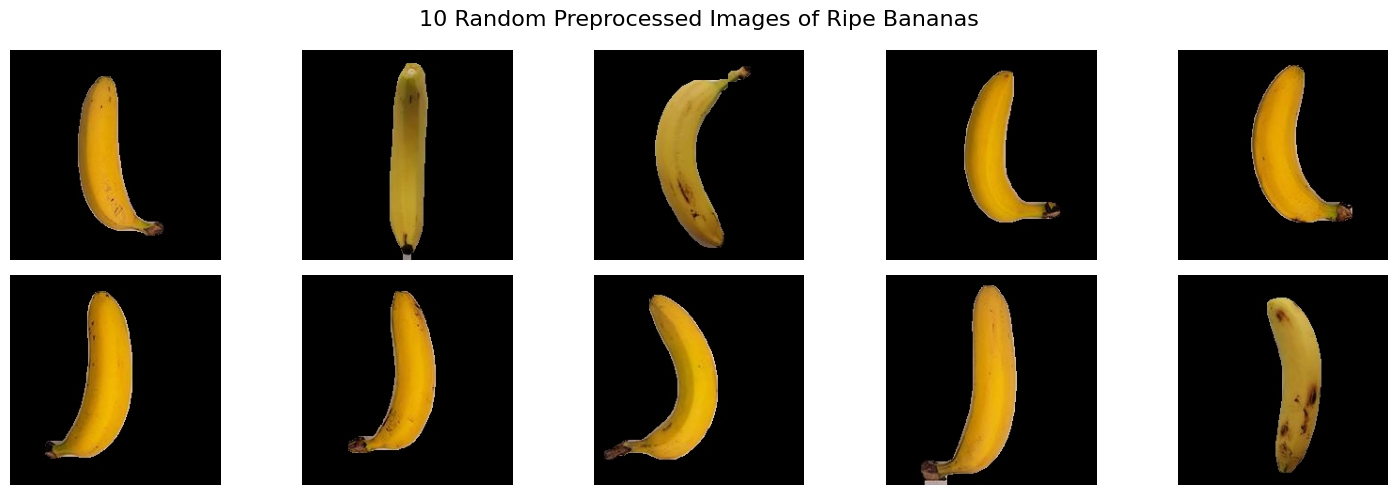

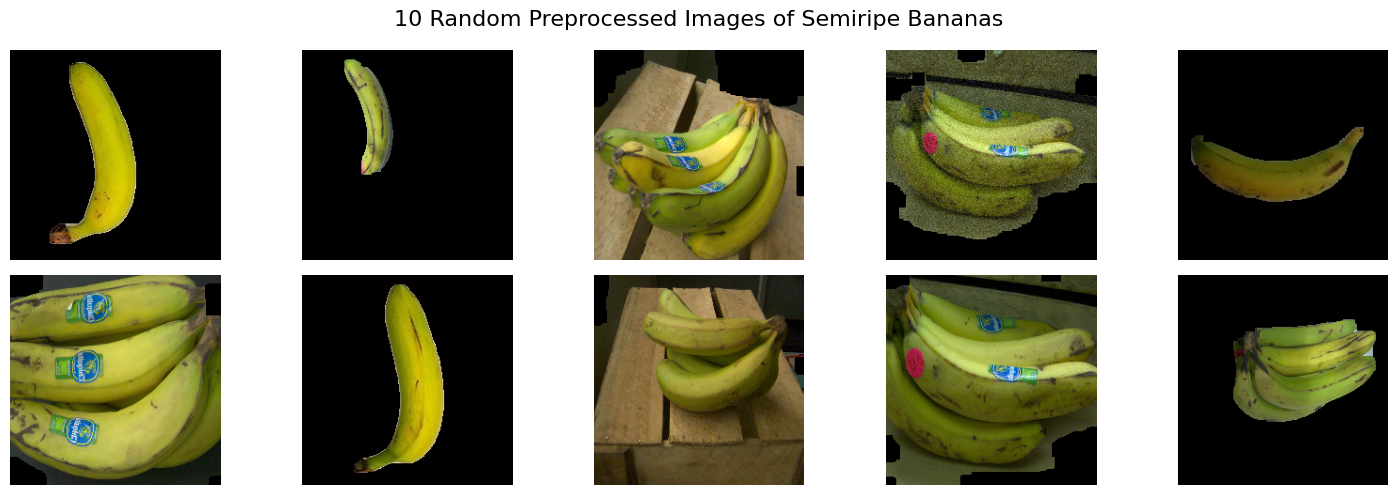

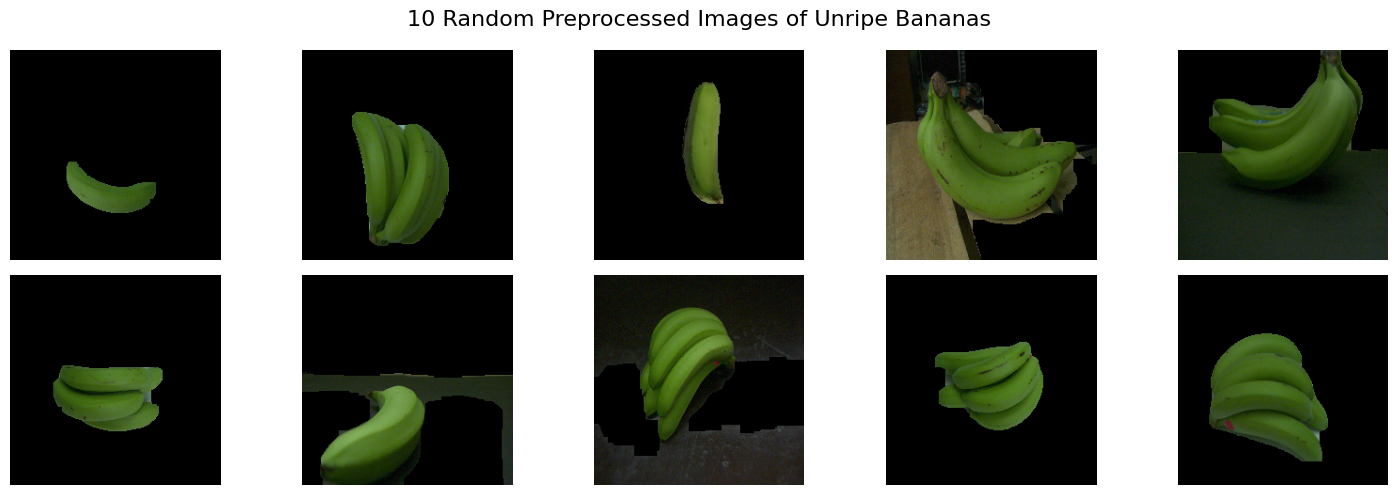

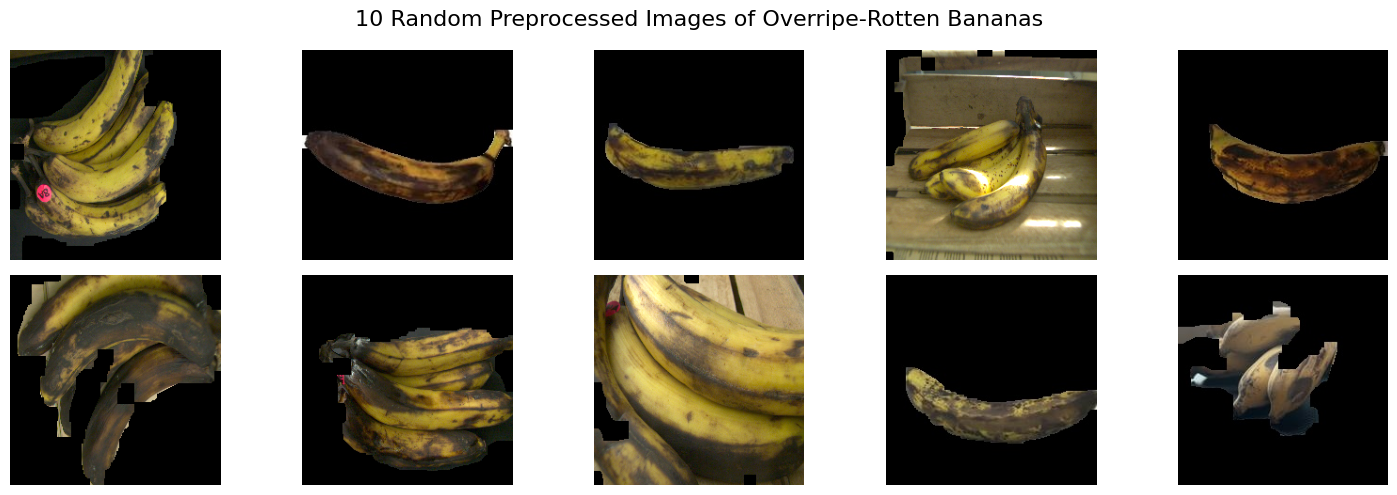

In [ ]:
# ==============================
# 7. VISUALIZATION OF PREPROCESSED DATASET
# ==============================

for category in ["Ripe", "Semiripe", "Unripe", "Overripe-Rotten"]:
    category_folder = os.path.join(save_dir, category)
    if not os.path.exists(category_folder):
        print(f"Skipping visualization: {category} folder not found in Preprocessed > Experiment_1")
        continue

    image_files = os.listdir(category_folder)

    if len(image_files) == 0:
        print(f"No preprocessed images found for {category}")
        continue

    # Select 10 random images for visualization
    sample_images = random.sample(image_files, min(10, len(image_files)))

    plt.figure(figsize=(15, 5))
    plt.suptitle(f"10 Random Preprocessed Images of {category} Bananas", fontsize=16)

    for i, image_name in enumerate(sample_images):
        image_path = os.path.join(category_folder, image_name)
        img = cv2.imread(image_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(2, 5, i + 1)
        plt.imshow(img)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

In [7]:
# ==============================
# 8. PROCESSING OWN DATASET (Resize First)
# ==============================
detector = BananaRipenessDetector()

# Define new input and output directories
new_data_dir = "/content/drive/MyDrive/TCV BANANA/Real Dataset/Preprocessed/Own"
new_save_dir = "/content/drive/MyDrive/TCV BANANA/Real Dataset/Preprocessed/Experiment_1/OwnDataset"
os.makedirs(new_save_dir, exist_ok=True)

# Process all images in the new dataset
for category in ["Ripe", "Semiripe", "Unripe", "Overripe-Rotten"]:
    folder_path = os.path.join(new_data_dir, category)
    if not os.path.exists(folder_path):
        print(f"Directory not found: {folder_path}")
        continue

    image_files = os.listdir(folder_path)
    print(f"Processing {len(image_files)} images in {category}")

    # Create output directory for this class
    category_save_dir = os.path.join(new_save_dir, category)
    os.makedirs(category_save_dir, exist_ok=True)

    for image_name in image_files:
        image_path = os.path.join(folder_path, image_name)
        original = cv2.imread(image_path)
        if original is None:
            continue

        # Step 1: Resize image to 224x224 before preprocessing
        resized_image = cv2.resize(original, (224, 224), interpolation=cv2.INTER_AREA)

        # Step 2: Perform preprocessing on resized image
        denoised = denoise_image(resized_image)
        enhanced = enhance_contrast(denoised)
        hsv = convert_to_hsv(enhanced)

        # Step 3: Extract banana
        banana_extracted, banana_mask = detector.extract_banana(hsv, resized_image, enhanced)

        # Save processed image
        if banana_extracted is not None:
            save_path = os.path.join(category_save_dir, image_name)
            cv2.imwrite(save_path, banana_extracted)

    print(f"Completed processing and saving extracted bananas for {category}\n")

Processing 70 images in Ripe
Completed processing and saving extracted bananas for Ripe

Processing 70 images in Semiripe
Completed processing and saving extracted bananas for Semiripe

Processing 70 images in Unripe
Completed processing and saving extracted bananas for Unripe

Processing 70 images in Overripe-Rotten
Completed processing and saving extracted bananas for Overripe-Rotten



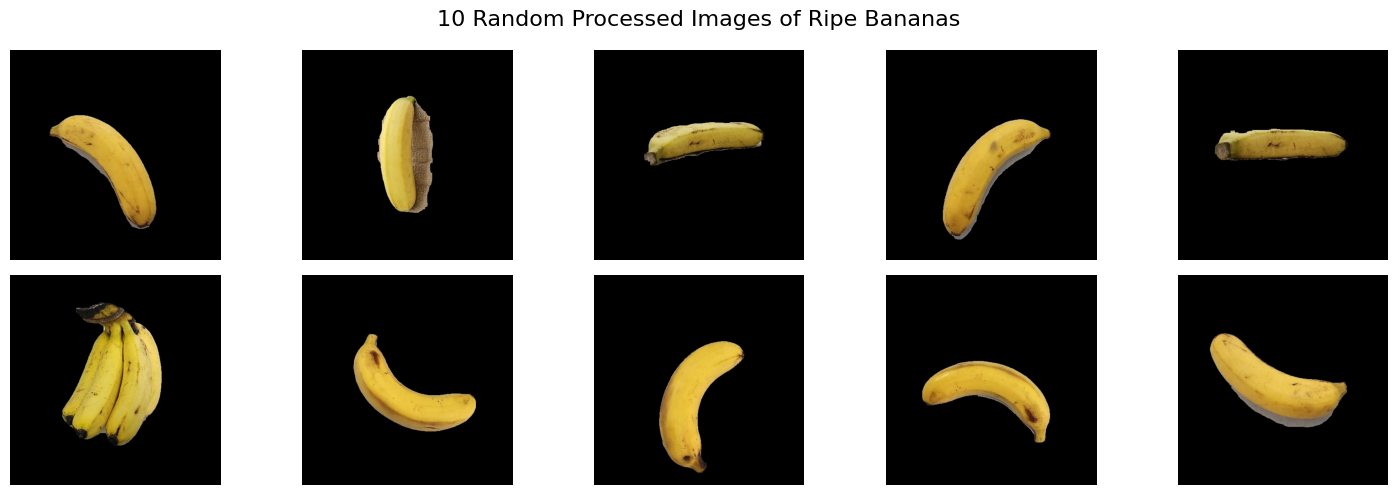

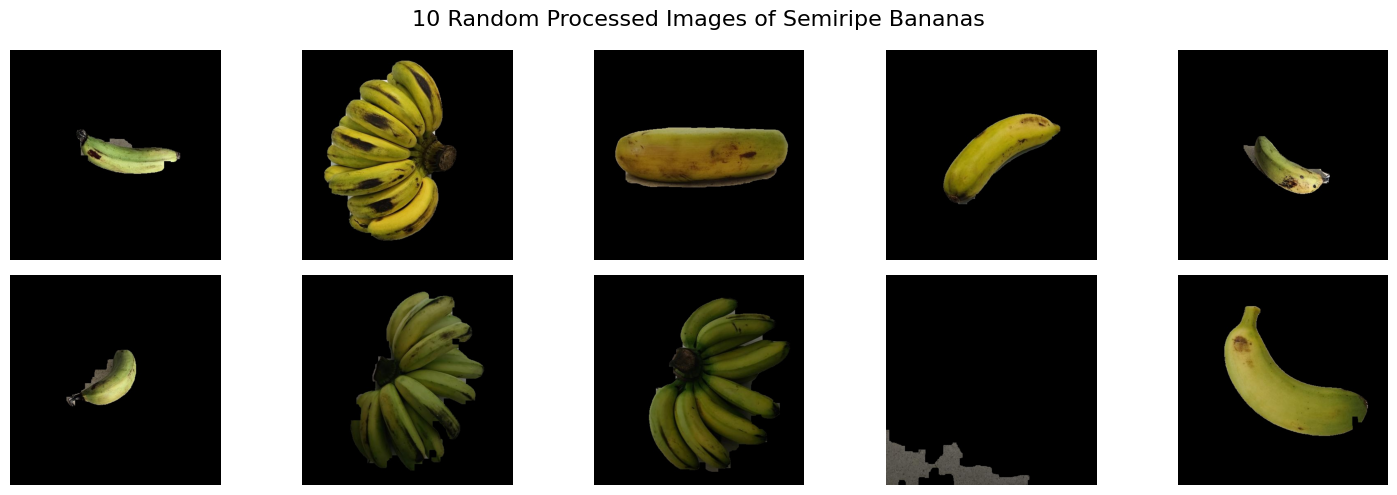

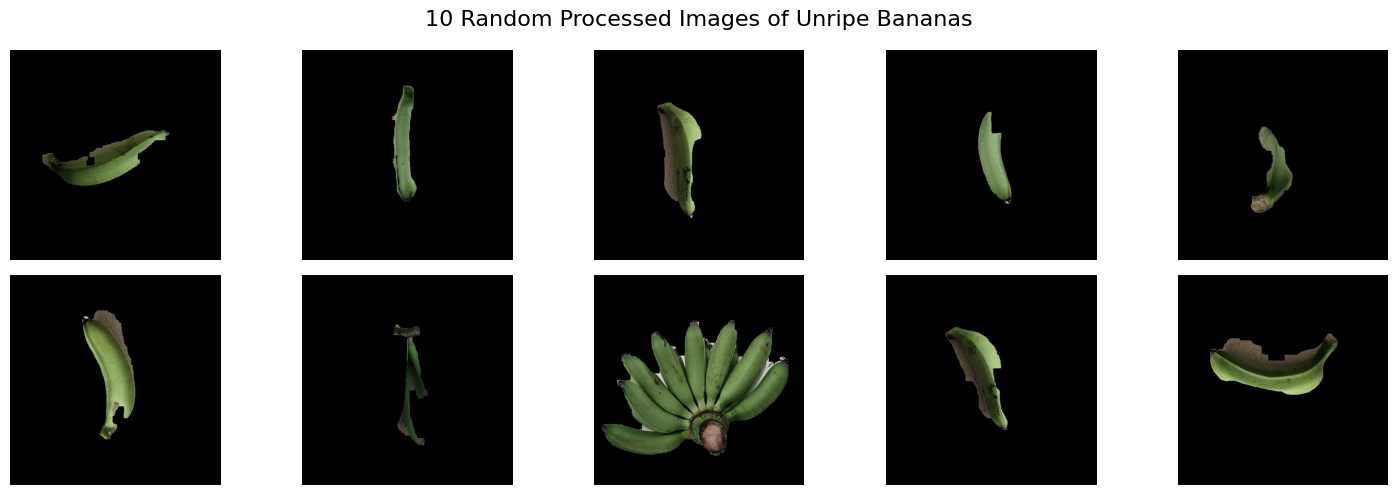

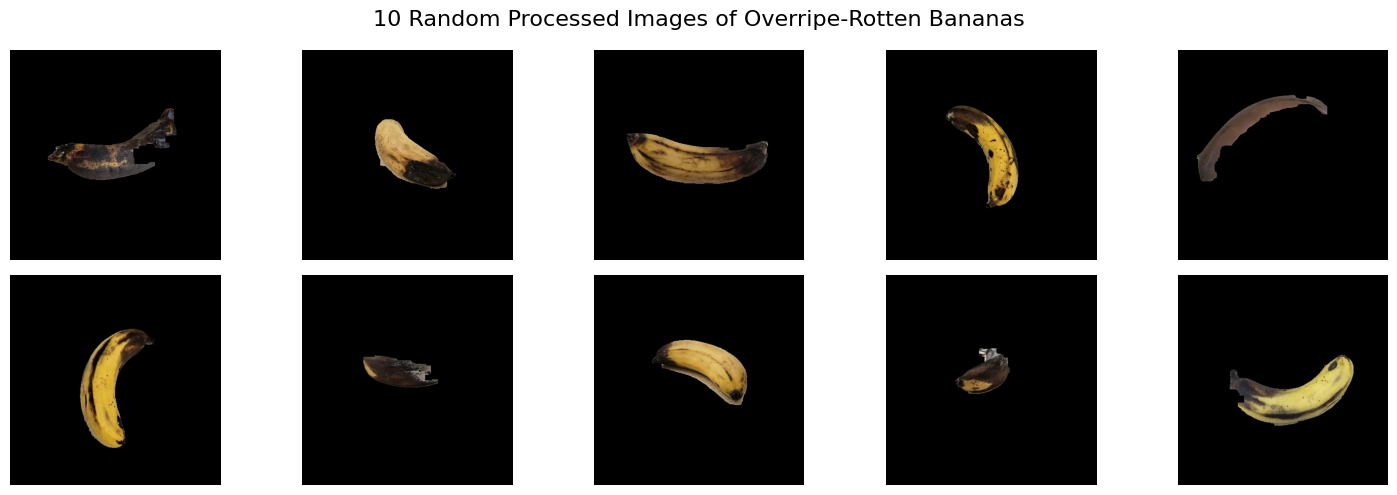

In [7]:
# ==============================
# 9. LOAD & VISUALIZE 10 RANDOM PROCESSED IMAGES PER CLASS
# ==============================

for category in ["Ripe", "Semiripe", "Unripe", "Overripe-Rotten"]:
    category_save_dir = os.path.join(new_save_dir, category)
    if not os.path.exists(category_save_dir):
        print(f"Skipping visualization: {category} folder not found in Experiment_1 > Own")
        continue

    saved_images = os.listdir(category_save_dir)

    if len(saved_images) == 0:
        print(f"No saved images found for {category}")
        continue

    # Select 10 random images for visualization
    sample_images = random.sample(saved_images, min(10, len(saved_images)))

    plt.figure(figsize=(15, 5))
    plt.suptitle(f"10 Random Processed Images of {category} Bananas", fontsize=16)

    for i, image_name in enumerate(sample_images):
        image_path = os.path.join(category_save_dir, image_name)
        img = cv2.imread(image_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert for visualization

        plt.subplot(2, 5, i + 1)  # 2 rows, 5 columns grid
        plt.imshow(img)
        plt.axis('off')

    plt.tight_layout()
    plt.show()